ZEUS Case: Multi-Electron Trajectory Tracking

This notebook analyzes a ZEUS-relevant near-infrared laser wakefield case with the following plasma and laser parameters:

$$
n_e = 2 \times 10^{16}\ \mathrm{cm}^{-3}, \qquad
\lambda_0 = 0.8\ \mu\mathrm{m}, \qquad
w_0 = 75\ \mu\mathrm{m},
$$

$$
a_0 = 3.66, \qquad
\tau = 25\ \mathrm{fs}.
$$

In normalized plasma units, this corresponds to

$$
k_p w_0 = 1.99, \qquad
k_p c \tau = 0.199.
$$

This notebook tracks multiple test-electron trajectories in the wakefield generated by this ZEUS parameter set. It creates separate one-electron input files with different initial transverse positions, runs them using the multi-core processing capability of a personal computer, and then loads the resulting debug trajectory files for comparison and visualization. A simpler single-electron version of this analysis is available in the `ZEUS2e16_single_track` notebook in the same folder.

In [2]:
from pathlib import Path
import os
import sys

project_root = Path.cwd().resolve()

while not (project_root / "main.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Could not find QuEP project root containing main.py.")
    project_root = project_root.parent

os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Working directory set to:", project_root)

Working directory set to: /Users/navidv/GitHub/QuEP


In [3]:
from pathlib import Path

core_name = "Zeus2e16"

cases = [
    {"tag": "p00", "y_c": 0.0, "x_c": 0.25, "xi_c": 0.30},
    {"tag": "p01", "y_c": 0.0, "x_c": 0.50, "xi_c": 0.30},
    {"tag": "p02", "y_c": 0.0, "x_c": 0.75, "xi_c": 0.30},
    {"tag": "p03", "y_c": 0.0, "x_c": 1.00, "xi_c": 0.30},
    {"tag": "p04", "y_c": 0.0, "x_c": 1.25, "xi_c": 0.30},
    {"tag": "p05", "y_c": 0.0, "x_c": 1.50, "xi_c": 0.30},
    {"tag": "p06", "y_c": 0.0, "x_c": 1.75, "xi_c": 0.30},
    {"tag": "p07", "y_c": 0.0, "x_c": 2.00, "xi_c": 0.30},
    {"tag": "p08", "y_c": 0.0, "x_c": 2.25, "xi_c": 0.30},
    {"tag": "p09", "y_c": 0.0, "x_c": 2.50, "xi_c": 0.30},
    {"tag": "p10", "y_c": 0.0, "x_c": 2.75, "xi_c": 0.30},
    {"tag": "p11", "y_c": 0.0, "x_c": 3.00, "xi_c": 0.30},
]

input_dir = project_root / "input"
input_dir.mkdir(exist_ok=True)

for case in cases:
    tag = case["tag"]
    module_name = f"{core_name}_{tag}"

    path = input_dir / f"{module_name}.py"

    text = f"""
simulation_name = "QUASI3D"

shape = "single"

iterations = 4000000

# mode 0 is wakefield, mode 1 is laser, mode -1 is both.
mode = -1

# Optional laser region in xi, in c/omega_p units.
laser_xi_start = -0.3
laser_xi_end = 0.3

# Output filename.
fname = "{module_name}.npz"

debugmode = True

# Probe centered at the following initial coordinates, in c/omega_p.
x_c = {case["x_c"]}
y_c = {case["y_c"]}
xi_c = {case["xi_c"]}

# Initial momentum.
px_0 = 0
py_0 = 0
pz_0 = 0

# Screen distances from z-axis of plasma cell, in mm.
x_s = [10, 50, 100, 250, 500]

# Shape parameters.
s1 = 1
s2 = 1

# Densities.
ydensity = 1
xidensity = 1
xdensity = 1
resolution = None

# Quasi3D simulation-specific parameters.
quasi_id = "000148"
quasi_data_dir = "data/OSIRIS/{core_name}"
quasi_density = 2e22
quasi_propagation_speed = 1.0
dt_safety_factor = 0.45
"""

    path.write_text(text.strip() + "\n")

    print(f"Wrote {path}")

Wrote /Users/navidv/GitHub/QuEP/input/Zeus2e16_p00.py
Wrote /Users/navidv/GitHub/QuEP/input/Zeus2e16_p01.py
Wrote /Users/navidv/GitHub/QuEP/input/Zeus2e16_p02.py
Wrote /Users/navidv/GitHub/QuEP/input/Zeus2e16_p03.py
Wrote /Users/navidv/GitHub/QuEP/input/Zeus2e16_p04.py
Wrote /Users/navidv/GitHub/QuEP/input/Zeus2e16_p05.py
Wrote /Users/navidv/GitHub/QuEP/input/Zeus2e16_p06.py
Wrote /Users/navidv/GitHub/QuEP/input/Zeus2e16_p07.py
Wrote /Users/navidv/GitHub/QuEP/input/Zeus2e16_p08.py
Wrote /Users/navidv/GitHub/QuEP/input/Zeus2e16_p09.py
Wrote /Users/navidv/GitHub/QuEP/input/Zeus2e16_p10.py
Wrote /Users/navidv/GitHub/QuEP/input/Zeus2e16_p11.py


### Run the particles in parallel
The following code needs to be run from a terminal or from and IDE like VSCode. If you run this inside Jupyter Notebook, it might crash because Jupyter does play nice with multi-core processes. 

```
from include.parallel_case_runner_pc import run_debug_cases

run_debug_cases(
    core_name="Zeus2e16",
    max_parallel=8,
)
```

In [4]:
import re

data_dir = project_root / "data"

pattern = re.compile(rf"^{re.escape(core_name)}_(p\d+)-DEBUG\.obj$")

debug_tags = []

for path in data_dir.glob(f"{core_name}_p*-DEBUG.obj"):
    match = pattern.match(path.name)

    if match:
        debug_tags.append(match.group(1))

debug_tags = sorted(debug_tags, key=lambda tag: int(tag[1:]))

print("Found completed debug tags:")
print(debug_tags)

Found completed debug tags:
['p00', 'p01', 'p02', 'p03', 'p04', 'p05', 'p06', 'p07', 'p08', 'p09', 'p10', 'p11']


In [5]:
import gc
import importlib
import pickle
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Clean up memory from earlier notebook cells.
gc.collect()

# Make sure imports work when the notebook is run from the project root.
project_root = Path.cwd()
print("Working directory set to:", project_root)

# -----------------------------------------------------------------------------
# Load one representative input file to configure the Quasi3D field infrastructure.
# The fields are the same for all five particles; only x_c/y_c/xi_c and fname differ.
# -----------------------------------------------------------------------------
input_module = "input.Zeus2e16_p00"
init = importlib.import_module(input_module)

import include.simulations.useQuasi3D as sim
sim.configure(init)

# -----------------------------------------------------------------------------
# Load all five debug trajectory objects.
# Each input fname was Zeus2e16_pXX.npz, so main.py should save
# data/Zeus2e16_pXX-DEBUG.obj.
# -----------------------------------------------------------------------------
debug_tags = ["p00", "p01", "p02", "p03", "p04"]
debugs = []

def load_debug_object(path):
    with open(path, "rb") as file:
        loaded = pickle.load(file)
    # main.py often saves Debug as a one-element list/tuple in this tutorial case.
    return loaded[0] if isinstance(loaded, (list, tuple)) else loaded

for tag in debug_tags:
    debug_file = project_root / "data" / f"Zeus2e16_{tag}-DEBUG.obj"
    debug = load_debug_object(debug_file)
    debug.tag = tag
    debugs.append(debug)
    print(f"Loaded {tag}: {debug_file}")

print(f"\nLoaded input module for fields: {init.__name__}")
print(f"Loaded {len(debugs)} debug trajectories.")
print("\nThe first Debug object contains:")
for key, value in debugs[0].__dict__.items():
    if key != "tag":
        print(f"{key:20s}  type={type(value).__name__:15s}  shape={np.shape(value)}")


Working directory set to: /Users/navidv/GitHub/QuEP
Using laser vector-potential region:
  xi range: -0.3 0.3
  index range: 10368 11231
Loaded p00: /Users/navidv/GitHub/QuEP/data/Zeus2e16_p00-DEBUG.obj
Loaded p01: /Users/navidv/GitHub/QuEP/data/Zeus2e16_p01-DEBUG.obj
Loaded p02: /Users/navidv/GitHub/QuEP/data/Zeus2e16_p02-DEBUG.obj
Loaded p03: /Users/navidv/GitHub/QuEP/data/Zeus2e16_p03-DEBUG.obj
Loaded p04: /Users/navidv/GitHub/QuEP/data/Zeus2e16_p04-DEBUG.obj

Loaded input module for fields: input.Zeus2e16_p00
Loaded 5 debug trajectories.

The first Debug object contains:
x_dat                 type=ndarray          shape=(1, 13061)
y_dat                 type=ndarray          shape=(1, 13061)
z_dat                 type=ndarray          shape=(1, 13061)
xi_dat                type=ndarray          shape=(1, 13061)
Fx_dat                type=ndarray          shape=(1, 13061)
Fy_dat                type=ndarray          shape=(1, 13061)
Fz_dat                type=ndarray          shape=(1

In [6]:
import gc
import importlib
import pickle
import re
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Clean up memory from earlier notebook cells.
gc.collect()

# Make sure imports work when the notebook is run from the project root.
project_root = Path.cwd().resolve()
print("Working directory set to:", project_root)

# -----------------------------------------------------------------------------
# Find all completed debug trajectory files for this case.
#
# This looks for files like:
#     data/Zeus2e16_p00-DEBUG.obj
#     data/Zeus2e16_p01-DEBUG.obj
#     ...
#
# The core name, "Zeus2e16", is supplied only once through core_name.
# -----------------------------------------------------------------------------
data_dir = project_root / "data"

pattern = re.compile(rf"^{re.escape(core_name)}_(p\d+)-DEBUG\.obj$")

debug_files = []

for path in data_dir.glob(f"{core_name}_p*-DEBUG.obj"):
    match = pattern.match(path.name)

    if match:
        tag = match.group(1)
        debug_files.append((tag, path))

debug_files = sorted(debug_files, key=lambda item: int(item[0][1:]))

if not debug_files:
    raise FileNotFoundError(
        f"No completed debug files found matching "
        f"{data_dir}/{core_name}_p*-DEBUG.obj"
    )

debug_tags = [tag for tag, path in debug_files]

print("Found completed debug tags:")
print(debug_tags)

# -----------------------------------------------------------------------------
# Load one representative input file to configure the Quasi3D field infrastructure.
#
# The fields are the same for all particles; only x_c/y_c/xi_c and fname differ.
# Use the first completed debug tag as the representative case.
# -----------------------------------------------------------------------------
representative_tag = debug_tags[0]
input_module = f"input.{core_name}_{representative_tag}"

importlib.invalidate_caches()
sys.modules.pop(input_module, None)

init = importlib.import_module(input_module)

import include.simulations.useQuasi3D as sim
sim.configure(init)

# -----------------------------------------------------------------------------
# Load all completed debug trajectory objects.
# -----------------------------------------------------------------------------
debugs = []

def load_debug_object(path):
    with open(path, "rb") as file:
        loaded = pickle.load(file)

    # main.py often saves Debug as a one-element list/tuple in this tutorial case.
    return loaded[0] if isinstance(loaded, (list, tuple)) else loaded


for tag, debug_file in debug_files:
    debug = load_debug_object(debug_file)
    debug.tag = tag
    debug.source_file = debug_file
    debugs.append(debug)

    print(f"Loaded {tag}: {debug_file}")

print(f"\nLoaded input module for fields: {init.__name__}")
print(f"Loaded {len(debugs)} debug trajectories.")

print("\nThe first Debug object contains:")
for key, value in debugs[0].__dict__.items():
    if key not in ["tag", "source_file"]:
        print(f"{key:20s}  type={type(value).__name__:15s}  shape={np.shape(value)}")

Working directory set to: /Users/navidv/GitHub/QuEP
Found completed debug tags:
['p00', 'p01', 'p02', 'p03', 'p04', 'p05', 'p06', 'p07', 'p08', 'p09', 'p10', 'p11']
Using laser vector-potential region:
  xi range: -0.3 0.3
  index range: 10368 11231
Loaded p00: /Users/navidv/GitHub/QuEP/data/Zeus2e16_p00-DEBUG.obj
Loaded p01: /Users/navidv/GitHub/QuEP/data/Zeus2e16_p01-DEBUG.obj
Loaded p02: /Users/navidv/GitHub/QuEP/data/Zeus2e16_p02-DEBUG.obj
Loaded p03: /Users/navidv/GitHub/QuEP/data/Zeus2e16_p03-DEBUG.obj
Loaded p04: /Users/navidv/GitHub/QuEP/data/Zeus2e16_p04-DEBUG.obj
Loaded p05: /Users/navidv/GitHub/QuEP/data/Zeus2e16_p05-DEBUG.obj
Loaded p06: /Users/navidv/GitHub/QuEP/data/Zeus2e16_p06-DEBUG.obj
Loaded p07: /Users/navidv/GitHub/QuEP/data/Zeus2e16_p07-DEBUG.obj
Loaded p08: /Users/navidv/GitHub/QuEP/data/Zeus2e16_p08-DEBUG.obj
Loaded p09: /Users/navidv/GitHub/QuEP/data/Zeus2e16_p09-DEBUG.obj
Loaded p10: /Users/navidv/GitHub/QuEP/data/Zeus2e16_p10-DEBUG.obj
Loaded p11: /Users/navid

In [7]:
# Defining functions that allow fields to be called as needed.
def as_2d(arr):
    """Return an array with shape (n_particles, n_steps)."""
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr[None, :]
    return arr


def get_r_xi_from_debug(debug):
    """Extract r and xi trajectory arrays from one DebugObject."""
    x_dat = as_2d(debug.x_dat)
    y_dat = as_2d(debug.y_dat)
    xi_dat = as_2d(debug.xi_dat)

    r_dat = np.sqrt(x_dat**2 + y_dat**2)
    return r_dat, xi_dat


def symmetric_color_limits(field, percentile=99):
    """Choose symmetric color limits using a percentile to avoid outlier domination."""
    vmax = np.nanpercentile(np.abs(field), percentile)
    return -vmax, vmax


def plot_field_with_debug_trajectories(
    xi_axis,
    r_axis,
    field,
    debug_objects,
    *,
    title,
    field_label,
    xlim=None,
    ylim=None,
    vmin=None,
    vmax=None,
    cmap="RdBu_r",
):
    """Plot a Quasi3D field in (xi, r) and overlay one or more debug trajectories."""
    if not isinstance(debug_objects, (list, tuple)):
        debug_objects = [debug_objects]

    if vmin is None or vmax is None:
        auto_vmin, auto_vmax = symmetric_color_limits(field)
        vmin = auto_vmin if vmin is None else vmin
        vmax = auto_vmax if vmax is None else vmax

    fig, ax = plt.subplots(figsize=(9, 5), dpi=130)

    mesh = ax.pcolormesh(
        xi_axis,
        r_axis,
        field,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    for debug in debug_objects:
        r_dat, xi_dat = get_r_xi_from_debug(debug)
        tag = getattr(debug, "tag", None)
        for i in range(r_dat.shape[0]):
            label = tag if i == 0 else None
            ax.plot(
                xi_dat[i, :],
                r_dat[i, :],
                linewidth=1.5,
                label=label,
            )

    ax.set_xlabel(r"$\xi$ $(c/\omega_p)$")
    ax.set_ylabel(r"$r$ $(c/\omega_p)$")
    ax.set_title(title)

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    if len(debug_objects) > 0:
        ax.legend(loc="best", title="particle")

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(field_label)

    fig.tight_layout()
    plt.show()


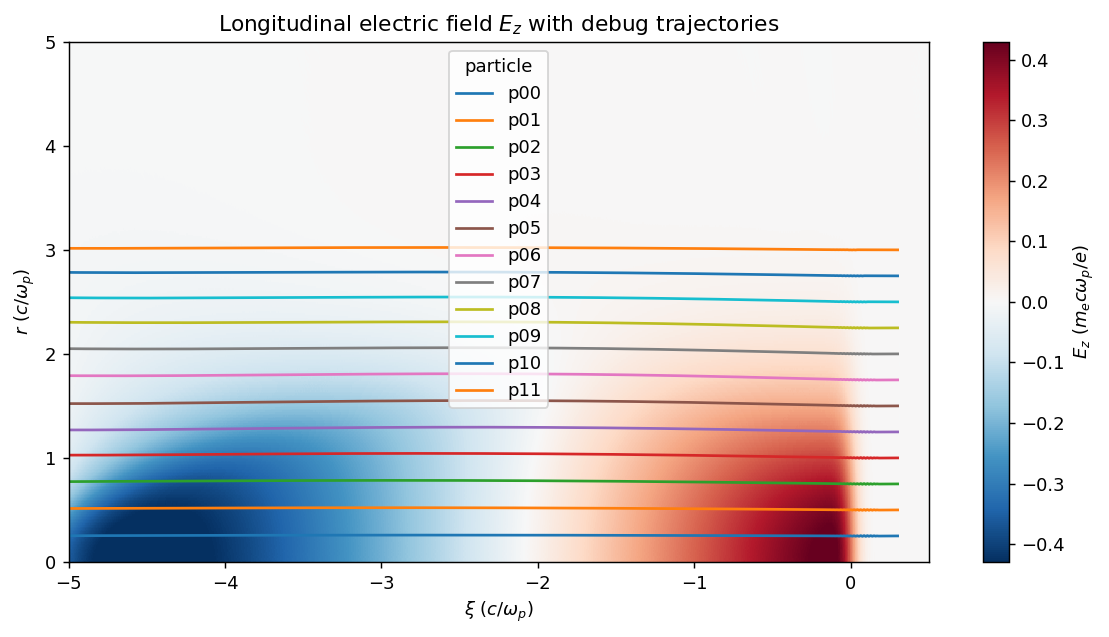

In [8]:
# Longitudinal electric field with the debug trajectory overlaid.
# E1_M0 lives on (xiaxis_1, raxis_2).
plot_field_with_debug_trajectories(
    sim.xiaxis_1,
    sim.raxis_2,
    sim.E1_M0,
    debugs,
    title=r"Longitudinal electric field $E_z$ with debug trajectories",
    field_label=r"$E_z$ $(m_e c \omega_p/e)$",
    # xlim=(-5, 6),
    xlim=(-5, 0.5),
    ylim=(0, 5),
    # vmin=0.5,
    # vmax=0.7
)

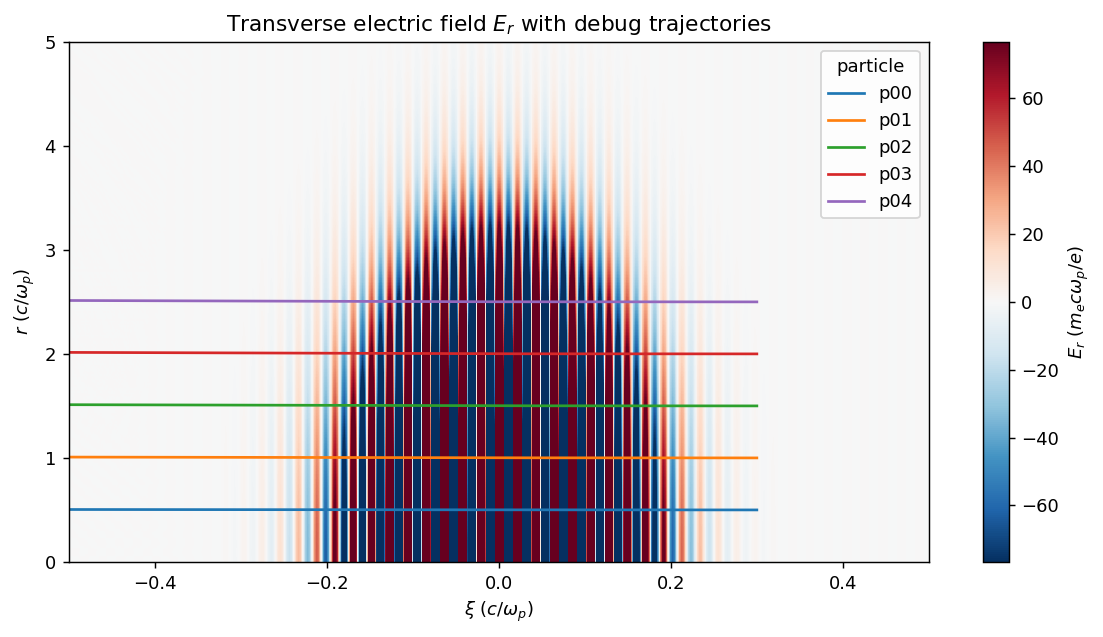

In [8]:
# Transverse/radial electric field with the debug trajectory overlaid.
# For mode 0 and phi = 0, E2_M0 corresponds to the radial/transverse field.
# E2_M0 lives on (xiaxis_2, raxis_1).
plot_field_with_debug_trajectories(
    sim.xiaxis_2,
    sim.raxis_1,
    sim.E2_M1_Re,
    debugs,
    title=r"Transverse electric field $E_r$ with debug trajectories",
    field_label=r"$E_r$ $(m_e c \omega_p/e)$",
    xlim=(-0.5, 0.5),
    ylim=(0, 5),
)

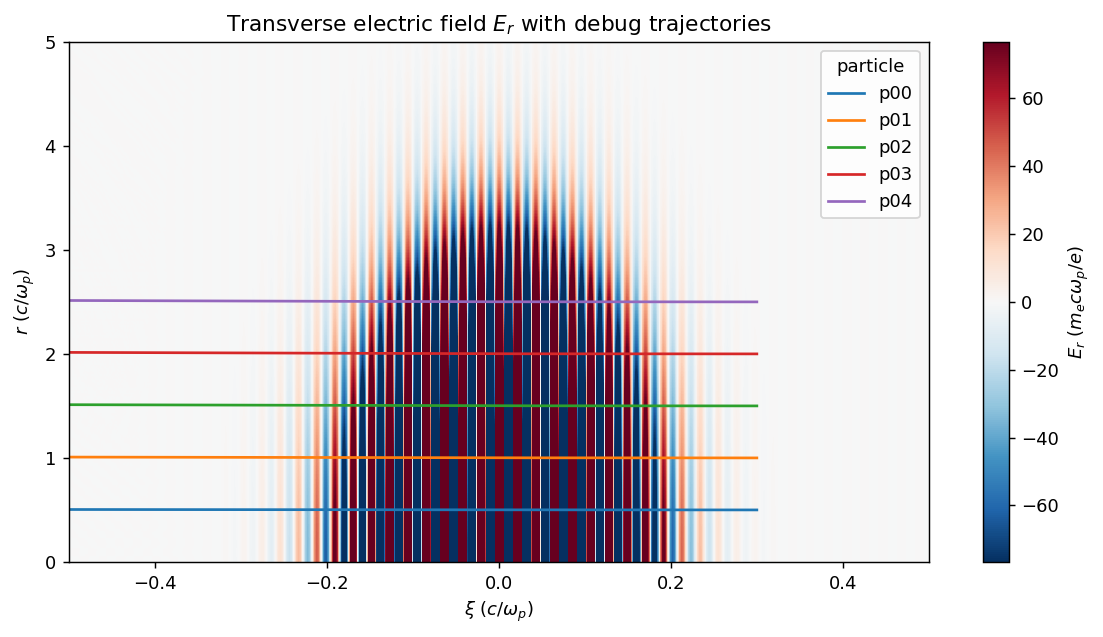

In [9]:
# Transverse/radial electric field with the debug trajectory overlaid.
# For mode 0 and phi = 0, E2_M0 corresponds to the radial/transverse field.
# E2_M0 lives on (xiaxis_2, raxis_1).
plot_field_with_debug_trajectories(
    sim.xiaxis_2,
    sim.raxis_1,
    sim.E2_M1_Re,
    debugs,
    title=r"Transverse electric field $E_r$ with debug trajectories",
    field_label=r"$E_r$ $(m_e c \omega_p/e)$",
    xlim=(-0.5, 0.5),
    ylim=(0, 5),
)